# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [11]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [12]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [13]:
A @ e_1

print("A @ e_1 =", A @ e_1)

A @ e_1 = [1 4 7]


Observation - 
This selects the first column of 𝐴, because multiplying by 𝑒1 picks out the contribution from the first column only.

In [14]:
A @ e_2

print("A @ e_1 =", A @ e_2)

A @ e_1 = [2 5 8]


Observation - This selects the second column of 𝐴, because 𝑒2 has a 1 in the second position.

In [15]:
A @ e_3

print("A @ e_1 =", A @ e_3)

A @ e_1 = [3 6 9]


Observation - This selects the third column of 𝐴, because 𝑒3 isolates the third component in each row.

Note :

- Each standard basis vector 𝑒𝑖 has a 1 in the 𝑖-th position and 0 elsewhere. 
- So when you compute 𝐴𝑒𝑖, you're effectively taking a linear combination of the columns of 𝐴, weighted by the entries in 𝑒𝑖.
- Since only one entry is non-zero (and equal to 1), you just get the corresponding column of 𝐴.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [16]:
u = np.ones(3)

In [17]:
A @ u

print("A @ e_1 =", A @ u)

A @ e_1 = [ 6. 15. 24.]


- Matrix multiplication means taking the dot product of each row of 𝐴 with the vector 𝑢
    - First row: 1⋅1 + 2⋅1 + 3⋅1 = 6
    - Second row: 4⋅1 + 5⋅1 + 6⋅1 = 15
    - Third row: 7⋅1 + 8⋅1 + 9⋅1 = 24

- Each entry in the resulting vector is the sum of the elements in the corresponding row of 𝐴.

- Because multiplying by 𝑢 = (1,1,1) means you're taking a weighted sum of the columns, with each column weighted by 1. So you're effectively summing all columns together, row by row.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [18]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])


In [19]:
result = A @ x
print(result)

[-2  4 11]


Explanation:

- Each row of the identity matrix has a single 1 in a unique position.

- So when you multiply 𝐴⋅𝑥, each row picks out exactly one component of 𝑥.

- The result is exactly the same as 𝑥.

The identity matrix acts like the number 1 in scalar multiplication—it doesn’t change the vector. It’s the neutral element in matrix multiplication.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [20]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])

x = np.array([-2,4,11])


In [21]:
result = A @ x
print(result)

[11 -2  4]


Let’s break it down row by row:

- Row 1: [0, 0, 1] → picks the third element of x → 11

- Row 2: [1, 0, 0] → picks the first element of x → -2

- Row 3: [0, 1, 0] → picks the second element of x → 4

This matrix permutes the vector 𝑥 by reordering its elements.

In [22]:
# new matrix B with rows & columns sum to 1

B = np.array([[0, 1, 0],
              [0, 0, 1],
              [1, 0, 0]])

result_B = B @ x
print(result_B)

[ 4 11 -2]


Explanation :

- These matrices are permutation matrices.

- They preserve the sum of rows and columns (each sums to 1).

- They reorder the elements of a vector without changing their values.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [23]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [24]:
A @ e_1
A @ e_2
A @ e_3


array([0.18358131, 0.37907577, 0.43734292])

In [25]:
print("A @ e_1 =", A @ e_1)
print("A @ e_2 =", A @ e_2)
print("A @ e_3 =", A @ e_3)

A @ e_1 = [0.50052958 0.02574731 0.47372311]
A @ e_2 = [0.24049286 0.39251588 0.36699127]
A @ e_3 = [0.18358131 0.37907577 0.43734292]


Interpretation :

- Each multiplication 𝐴⋅𝑒𝑗 selects the 𝑗-th column of 𝐴. Why?

- Because multiplying by 𝑒𝑗 isolates the 𝑗-th column:

    - 𝐴⋅𝑒1 = column 1 of 𝐴 ; Starting in state 1, this gives the probabilities of transitioning to states 1, 2, and 3.
    - 𝐴⋅𝑒2 = column 2 of 𝐴 ; Starting in state 2, this gives the transition probabilities to each state.
    - 𝐴⋅𝑒3 = column 3 of 𝐴 ; Starting in state 3, same idea.

Each result is a probability distribution over the next state, given that we started in state 𝑗.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [26]:
# Function to apply Markov process
def apply_markov(A, x, steps=5):
    for _ in range(steps):
        x = A @ x
    return x

# Function to print each step
def print_markov_steps(A, x, label):
    print(f"\nStarting from {label}:")
    for i in range(1, 6):
        x = A @ x
        print(f"Step {i}: {x}")

# Run for each starting vector
print_markov_steps(A, e_1, "e1")
print_markov_steps(A, e_2, "e2")
print_markov_steps(A, e_3, "e3")


Starting from e1:
Step 1: [0.50052958 0.02574731 0.47372311]
Step 2: [0.34368862 0.20257047 0.45374091]
Step 3: [0.30404142 0.26036337 0.43559521]
Step 4: [0.29476439 0.27514859 0.43008701]
Step 5: [0.29266551 0.27862515 0.42870935]

Starting from e2:
Step 1: [0.24049286 0.39251588 0.36699127]
Step 2: [0.28214379 0.29937825 0.41847795]
Step 3: [0.29004438 0.28341002 0.42654561]
Step 4: [0.29163968 0.2804039  0.42795643]
Step 5: [0.29197422 0.27979983 0.42822595]

Starting from e3:
Step 1: [0.18358131 0.37907577 0.43734292]
Step 2: [0.26334088 0.31930609 0.41735304]
Step 3: [0.28521895 0.29032145 0.4244596 ]
Step 4: [0.29050361 0.28220175 0.42729464]
Step 5: [0.29171646 0.2802254  0.42805814]


In [27]:
result_e1 = apply_markov(A, e_1)
result_e2 = apply_markov(A, e_2)
result_e3 = apply_markov(A, e_3)

print("After 5 steps starting from e1:", result_e1)
print("After 5 steps starting from e2:", result_e2)
print("After 5 steps starting from e3:", result_e3)

After 5 steps starting from e1: [0.29266551 0.27862515 0.42870935]
After 5 steps starting from e2: [0.29197422 0.27979983 0.42822595]
After 5 steps starting from e3: [0.29171646 0.2802254  0.42805814]


Observation :

- Each step redistributes the probabilities.

- After 5 steps, all three starting vectors will converge toward a similar distribution.

- This distribution is the stationary distribution of the Markov chain.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [28]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

x = np.array([1, 0])  # Start in state 1

In [29]:
x1 = T @ x
print("After one step:", x1)

After one step: [0.25 0.75]


- T ; Markov transition matrix, where each column represents the probabilities of transitioning from a state, and each entry 𝑝𝑖←𝑗 is the probability of moving to state 𝑖 from state 𝑗.
- State 1 ; This means 100% of the population is in state 1 at time 𝑡 = 0.

After one time step:

- 25% of the population is in state 1

- 75% is in state 2

This is a one-step forecast of the system’s state proportions.

- This result is a probability distribution vector over the states at time 𝑡 = 1. 

- It tells you the expected proportion of the population in each state after one transition, assuming everyone started in state 1.

In [30]:
# Second transition (Step #2)

x2 = T @ x1
print("Step 2:", x2)

Step 2: [0.4375 0.5625]


Explanation 
- x2 is a new probability distribution vector that represents forecasted state proportions two periods ahead, starting from original condition i.e state 1.

- It’s a weighted blend of the columns of 𝑇, based on the distribution from step 1.

- This shows how the system evolves over time — not just immediate transitions, but cumulative effects.

In [31]:
# Third transition (Step #3)

# Iterate and print each step
print("Markov chain evolution starting from state 1:")
for i in range(1, 20):
    x = T @ x
    print(f"Step {i}: {x}")

Markov chain evolution starting from state 1:
Step 1: [0.25 0.75]
Step 2: [0.4375 0.5625]
Step 3: [0.390625 0.609375]
Step 4: [0.40234375 0.59765625]
Step 5: [0.39941406 0.60058594]
Step 6: [0.40014648 0.59985352]
Step 7: [0.39996338 0.60003662]
Step 8: [0.40000916 0.59999084]
Step 9: [0.39999771 0.60000229]
Step 10: [0.40000057 0.59999943]
Step 11: [0.39999986 0.60000014]
Step 12: [0.40000004 0.59999996]
Step 13: [0.39999999 0.60000001]
Step 14: [0.4 0.6]
Step 15: [0.4 0.6]
Step 16: [0.4 0.6]
Step 17: [0.4 0.6]
Step 18: [0.4 0.6]
Step 19: [0.4 0.6]


Observation :

- The vector will gradually converge toward a stable distribution.

- Around step 6–7, the values will stop changing significantly.

- That’s your stationary distribution, where the Markov chain has settled.

In [32]:
# Repeat for starting from state 2

T = np.array([[0.25, 0.5],
              [0.75, 0.5]])

x = np.array([0, 1])  # Start in state 2

print("Markov chain evolution starting from state 2:")
for i in range(1, 20):
    x = T @ x
    print(f"Step {i}: {x}")

Markov chain evolution starting from state 2:
Step 1: [0.5 0.5]
Step 2: [0.375 0.625]
Step 3: [0.40625 0.59375]
Step 4: [0.3984375 0.6015625]
Step 5: [0.40039062 0.59960938]
Step 6: [0.39990234 0.60009766]
Step 7: [0.40002441 0.59997559]
Step 8: [0.3999939 0.6000061]
Step 9: [0.40000153 0.59999847]
Step 10: [0.39999962 0.60000038]
Step 11: [0.4000001 0.5999999]
Step 12: [0.39999998 0.60000002]
Step 13: [0.40000001 0.59999999]
Step 14: [0.4 0.6]
Step 15: [0.4 0.6]
Step 16: [0.4 0.6]
Step 17: [0.4 0.6]
Step 18: [0.4 0.6]
Step 19: [0.4 0.6]


Observation: 

- You get the same long-run result as when starting from state 1. 

- The Markov chain forgets its initial condition and settles into a stable equilibrium.

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
# Load the dataset
df = pd.read_csv("cville_weather.csv")

print(df.head())

       STATION                            NAME        DATE  DAPR  \
0  US1VACRC002  CHARLOTTESVILLE 0.5 NNE, VA US  2024-01-04   NaN   
1  US1VACRC002  CHARLOTTESVILLE 0.5 NNE, VA US  2024-01-07   NaN   
2  US1VACRC002  CHARLOTTESVILLE 0.5 NNE, VA US  2024-01-09   NaN   
3  US1VACRC002  CHARLOTTESVILLE 0.5 NNE, VA US  2024-01-10   NaN   
4  US1VACRC002  CHARLOTTESVILLE 0.5 NNE, VA US  2024-01-24   NaN   

  DAPR_ATTRIBUTES  MDPR MDPR_ATTRIBUTES  PRCP PRCP_ATTRIBUTES  SNOW  \
0             NaN   NaN             NaN  0.03             ,,N   NaN   
1             NaN   NaN             NaN  1.08             ,,N   NaN   
2             NaN   NaN             NaN  0.24             ,,N   NaN   
3             NaN   NaN             NaN  3.00             ,,N   NaN   
4             NaN   NaN             NaN  0.00             ,,N   0.0   

  SNOW_ATTRIBUTES  SNWD SNWD_ATTRIBUTES  
0             NaN   NaN             NaN  
1             NaN   NaN             NaN  
2             NaN   NaN             Na

In [47]:
# Display basic info
print("Dataset shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())


Dataset shape: (411, 13)

Missing values per column:
STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64


In [48]:
# preview rows with missing PRCP (precipitation)
missing_prcp = df[df['PRCP'].isna()]
print("\nRows with missing PRCP values:")
print(missing_prcp[['DATE', 'PRCP']])


Rows with missing PRCP values:
           DATE  PRCP
41   2024-03-05   NaN
69   2024-05-05   NaN
187  2024-09-25   NaN
197  2024-11-07   NaN
207  2024-11-28   NaN
209  2024-12-09   NaN
212  2024-12-15   NaN
272  2024-01-10   NaN
287  2024-02-12   NaN
295  2024-02-25   NaN
309  2024-05-17   NaN
410  2025-02-01   NaN


In [49]:
# Step 1: Create 'rain' variable (1 if PRCP > 0, else 0)
df['rain'] = (df['PRCP'] > 0).astype(int)

# Preview the result
print(df[['DATE', 'PRCP', 'rain']].head(10))

         DATE  PRCP  rain
0  2024-01-04  0.03     1
1  2024-01-07  1.08     1
2  2024-01-09  0.24     1
3  2024-01-10  3.00     1
4  2024-01-24  0.00     0
5  2024-01-25  0.18     1
6  2024-01-26  0.08     1
7  2024-01-27  0.00     0
8  2024-01-28  1.29     1
9  2024-01-29  0.19     1


In [50]:
# Step 2: Build two-state Markov chain
df['prev_rain'] = df['rain'].shift(1)
df = df.dropna(subset=['prev_rain'])
df['prev_rain'] = df['prev_rain'].astype(int)

In [51]:
# Transition matrix
transition_counts = pd.crosstab(df['prev_rain'], df['rain'])
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
print("Transition matrix:\n", transition_matrix)

Transition matrix:
 rain              0         1
prev_rain                    
0          0.731602  0.268398
1          0.351955  0.648045


In [52]:
# Step 3: Conditional probabilities
rain_after_clear = transition_matrix.loc[0, 1]
rain_after_rain = transition_matrix.loc[1, 1]
print(f"\nP(rain | clear) = {rain_after_clear:.4f}")
print(f"P(rain | rain)  = {rain_after_rain:.4f}")


P(rain | clear) = 0.2684
P(rain | rain)  = 0.6480


In [53]:
# Step 4: Forecasting from initial state
def forecast(initial_state, T, steps=10):
    x = np.array(initial_state)
    history = [x]
    for _ in range(steps):
        x = T @ x
        history.append(x)
    return np.array(history)

T = transition_matrix.values
forecast_clear = forecast([1, 0], T)
forecast_rain = forecast([0, 1], T)

In [54]:
print("\nForecast starting from clear day:")
for i, x in enumerate(forecast_clear):
    print(f"Step {i}: Clear={x[0]:.4f}, Rain={x[1]:.4f}")

print("\nForecast starting from rainy day:")
for i, x in enumerate(forecast_rain):
    print(f"Step {i}: Clear={x[0]:.4f}, Rain={x[1]:.4f}")


Forecast starting from clear day:
Step 0: Clear=1.0000, Rain=0.0000
Step 1: Clear=0.7316, Rain=0.3520
Step 2: Clear=0.6297, Rain=0.4856
Step 3: Clear=0.5910, Rain=0.5363
Step 4: Clear=0.5763, Rain=0.5556
Step 5: Clear=0.5708, Rain=0.5629
Step 6: Clear=0.5686, Rain=0.5656
Step 7: Clear=0.5678, Rain=0.5667
Step 8: Clear=0.5675, Rain=0.5671
Step 9: Clear=0.5674, Rain=0.5673
Step 10: Clear=0.5674, Rain=0.5673

Forecast starting from rainy day:
Step 0: Clear=0.0000, Rain=1.0000
Step 1: Clear=0.2684, Rain=0.6480
Step 2: Clear=0.3703, Rain=0.5144
Step 3: Clear=0.4090, Rain=0.4637
Step 4: Clear=0.4237, Rain=0.4444
Step 5: Clear=0.4292, Rain=0.4371
Step 6: Clear=0.4314, Rain=0.4344
Step 7: Clear=0.4322, Rain=0.4333
Step 8: Clear=0.4325, Rain=0.4329
Step 9: Clear=0.4326, Rain=0.4327
Step 10: Clear=0.4326, Rain=0.4327


In [55]:
# Forecast from clear day [1, 0] and rainy day [0, 1]
initial_clear = np.array([1, 0])
initial_rain = np.array([0, 1])

print("Starting from clear day:")
x = initial_clear.copy()
for i in range(1, 11):
    x = transition_matrix @ x
    print(f"Step {i}: {x}")

print("\nStarting from rainy day:")
x = initial_rain.copy()
for i in range(1, 11):
    x = transition_matrix @ x
    print(f"Step {i}: {x}")

Starting from clear day:
Step 1: prev_rain
0    0.731602
1    0.351955
dtype: float64
Step 2: prev_rain
0    0.629705
1    0.485574
dtype: float64
Step 3: prev_rain
0    0.591021
1    0.536302
dtype: float64
Step 4: prev_rain
0    0.576334
1    0.555560
dtype: float64
Step 5: prev_rain
0    0.570759
1    0.562872
dtype: float64
Step 6: prev_rain
0    0.568642
1    0.565648
dtype: float64
Step 7: prev_rain
0    0.567838
1    0.566701
dtype: float64
Step 8: prev_rain
0    0.567533
1    0.567101
dtype: float64
Step 9: prev_rain
0    0.567417
1    0.567253
dtype: float64
Step 10: prev_rain
0    0.567373
1    0.567311
dtype: float64

Starting from rainy day:
Step 1: prev_rain
0    0.268398
1    0.648045
dtype: float64
Step 2: prev_rain
0    0.370295
1    0.514426
dtype: float64
Step 3: prev_rain
0    0.408979
1    0.463698
dtype: float64
Step 4: prev_rain
0    0.423666
1    0.444440
dtype: float64
Step 5: prev_rain
0    0.429241
1    0.437128
dtype: float64
Step 6: prev_rain
0    0.431358
1

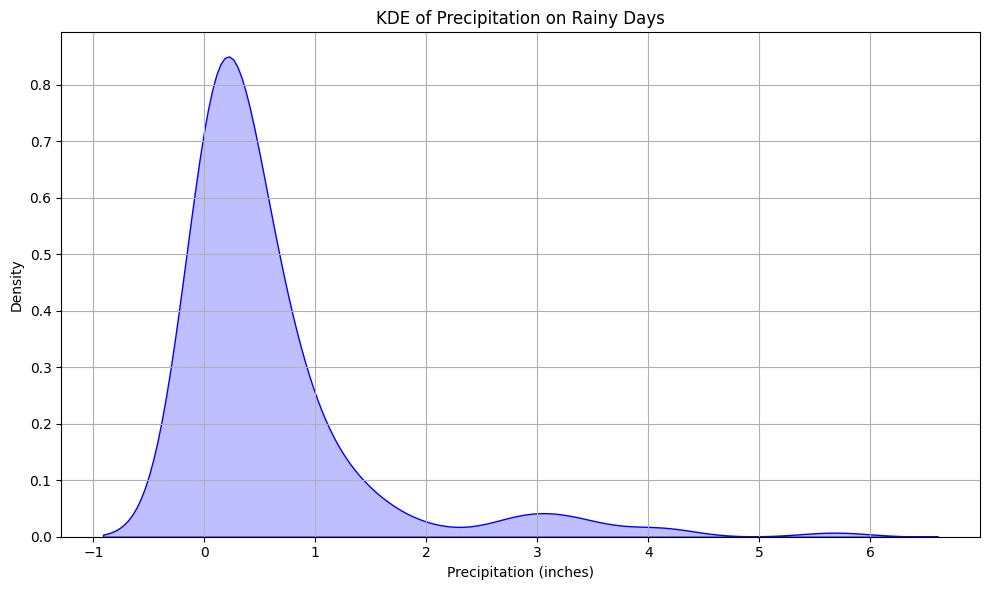

In [ ]:
# Filter to rainy days only
rainy_days = df[df['rain'] == 1]

# Step 5: KDE of PRCP on rainy days
plt.figure(figsize=(10, 6))
sns.kdeplot(rainy_days['PRCP'], fill=True, color='blue')
plt.title('KDE of Precipitation on Rainy Days')
plt.xlabel('Precipitation (inches)')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
# Step 6: Seasonal Markov chains
df['DATE'] = pd.to_datetime(df['DATE'])
df['month'] = df['DATE'].dt.month
df['prev_month'] = df['month'].shift(1)
df = df.dropna(subset=['prev_month'])
df['prev_month'] = df['prev_month'].astype(int)

In [57]:
monthly_chains = {}
for month in range(1, 13):
    subset = df[df['month'] == month]
    transition_counts = pd.crosstab(subset['prev_rain'], subset['rain'])
    transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    monthly_chains[month] = transition_matrix

print("\nExample: March Markov chain")
print(monthly_chains[3])


Example: March Markov chain
rain           0      1
prev_rain              
0          0.625  0.375
1          0.500  0.500


Note :

One powerful way to improve your weather forecasting and simulation model is to incorporate seasonality and temporal context into the Markov chain.

Instead of treating all days equally, build separate transition matrices for different seasons or months. For example:

- One matrix for winter months (higher persistence of dry spells or snow)

- Another for summer months (more frequent rain transitions)

- Or even finer: build monthly chains (January, February, etc.)


Why Markov Chains ?

- Weather patterns are not stationary year-round.

- Rain probabilities and persistence vary by season.

- A time-conditioned model captures seasonal dynamics, improving both forecast accuracy and realism in simulations.

What this does ?

- Builds 12 separate transition matrices, one for each month.

- Captures seasonal variation in rain persistence and switching.

- Enables month-aware forecasting for simulations or predictive models.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [58]:
import pickle
import pandas as pd

In [66]:
# Load pickled data
with open("/Users/khansaamaa/Downloads/lab data/taxicab.pkl", "rb") as f:
    trajectories = pickle.load(f)

##### - For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.

In [69]:
# Data Cleaning and Discretization

# remove empty or short trajectories
cleaned = [traj for traj in trajectories if len(traj) > 1]

# remove consecutive duplicates

def remove_repeats(traj):
    cleaned = []
    for pt in traj:
        if not cleaned or tuple(pt) != tuple(cleaned[-1]):
            cleaned.append(pt)
    return cleaned

# Apply to all trajectories
cleaned = [remove_repeats(list(traj)) for traj in trajectories if isinstance(traj, (list, tuple)) and len(traj) > 1]


# Optional: discretize GPS into grid cells
def discretize(pt, grid_size=0.01):
    lat, lon = pt
    return (round(lat / grid_size), round(lon / grid_size))

discretized = [[discretize(pt) for pt in traj] for traj in cleaned]

##### - Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?

In [70]:
# Flatten transitions into (from, to) pairs
transitions = []
for traj in trajectories:
    traj = list(traj)
    for i in range(len(traj) - 1):
        transitions.append((traj[i], traj[i + 1]))

# Create DataFrame and transition matrix
df = pd.DataFrame(transitions, columns=["from", "to"])
transition_counts = pd.crosstab(df["from"], df["to"])
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

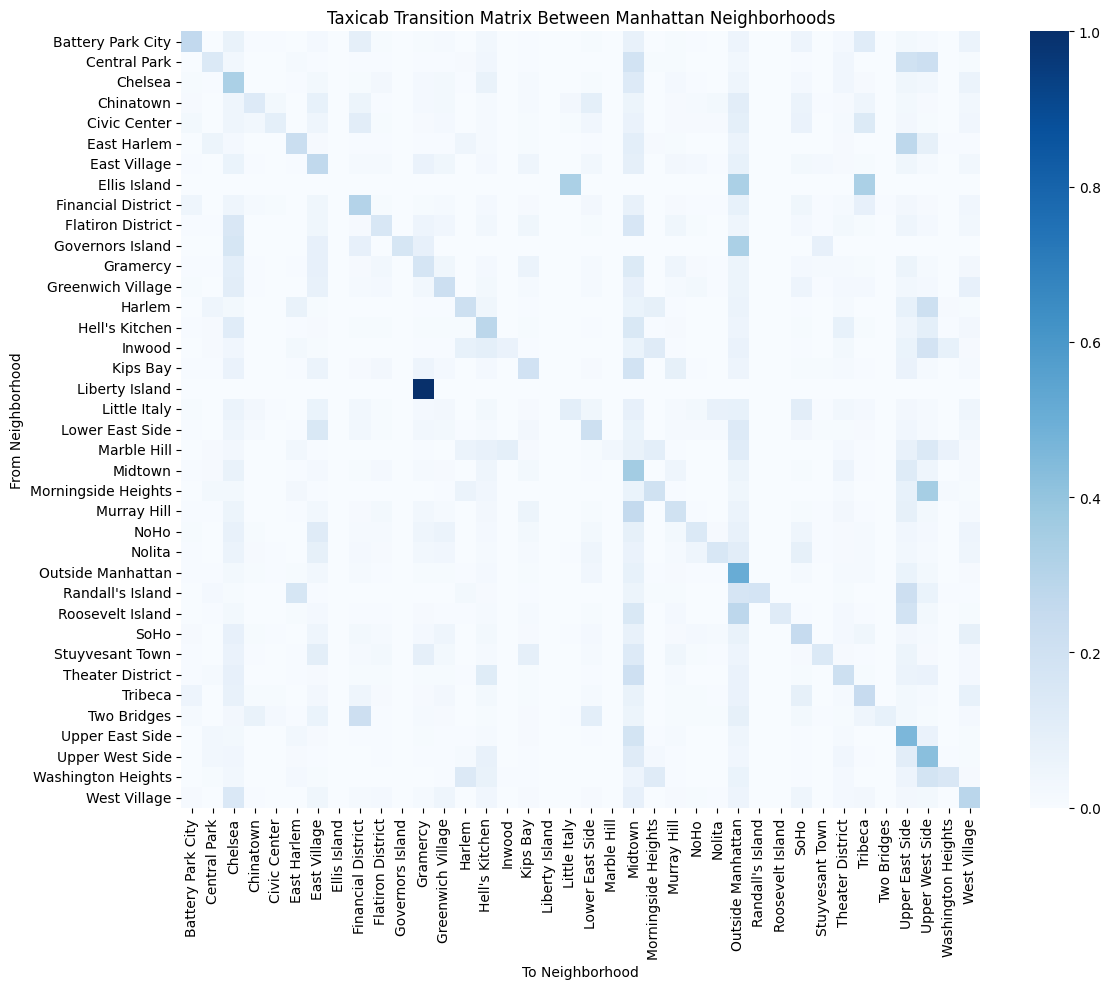

In [71]:
# head map of the transition matrix

plt.figure(figsize=(12, 10))
sns.heatmap(transition_matrix, cmap="Blues", annot=False)
plt.title("Taxicab Transition Matrix Between Manhattan Neighborhoods")
plt.xlabel("To Neighborhood")
plt.ylabel("From Neighborhood")
plt.tight_layout()
plt.show()


In [72]:
# Most Common Routes 

most_common = df.value_counts().head(10)
print("Most common routes:")
print(most_common)

Most common routes:
from               to               
Midtown            Midtown              1389343
Upper East Side    Upper East Side      1283151
Outside Manhattan  Outside Manhattan    1203902
Upper West Side    Upper West Side       763963
Chelsea            Chelsea               662397
Upper East Side    Midtown               507502
Midtown            Upper East Side       484395
Hell's Kitchen     Hell's Kitchen        346322
Midtown            Chelsea               278191
Chelsea            Midtown               260420
Name: count, dtype: int64


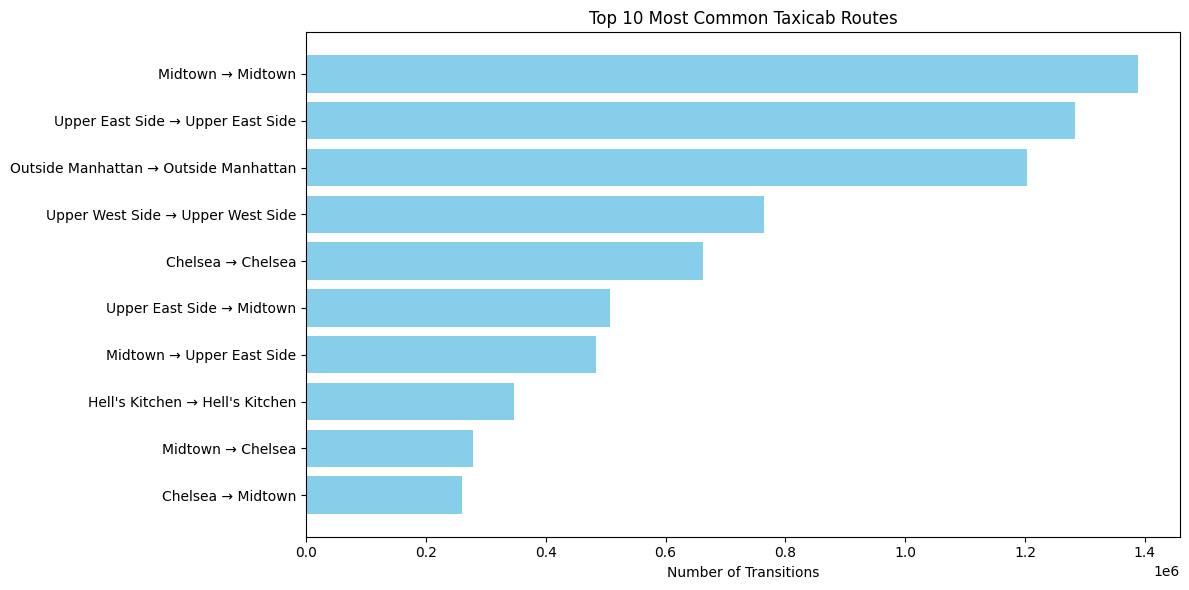

In [85]:
# Count frequency of each route
df = pd.DataFrame(transitions, columns=["from", "to"])
route_counts = df.value_counts().reset_index(name="count")

# Select top 10 most common routes
top_routes = route_counts.head(10)
labels = [f"{row['from']} → {row['to']}" for _, row in top_routes.iterrows()]
counts = top_routes['count']

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.barh(labels[::-1], counts[::-1], color="skyblue")
plt.title("Top 10 Most Common Taxicab Routes")
plt.xlabel("Number of Transitions")
plt.tight_layout()
plt.show()

In [74]:
# Initialize containers
transitions = []
trip_lengths = []
visited = []
loops = 0

# Process trajectories
for traj in trajectories:
    traj = list(traj)
    trip_lengths.append(len(traj))
    visited.extend(traj)
    if len(set(traj)) < len(traj):
        loops += 1
    for i in range(len(traj) - 1):
        transitions.append((traj[i], traj[i + 1]))

#### - Exploratory Data Analysis

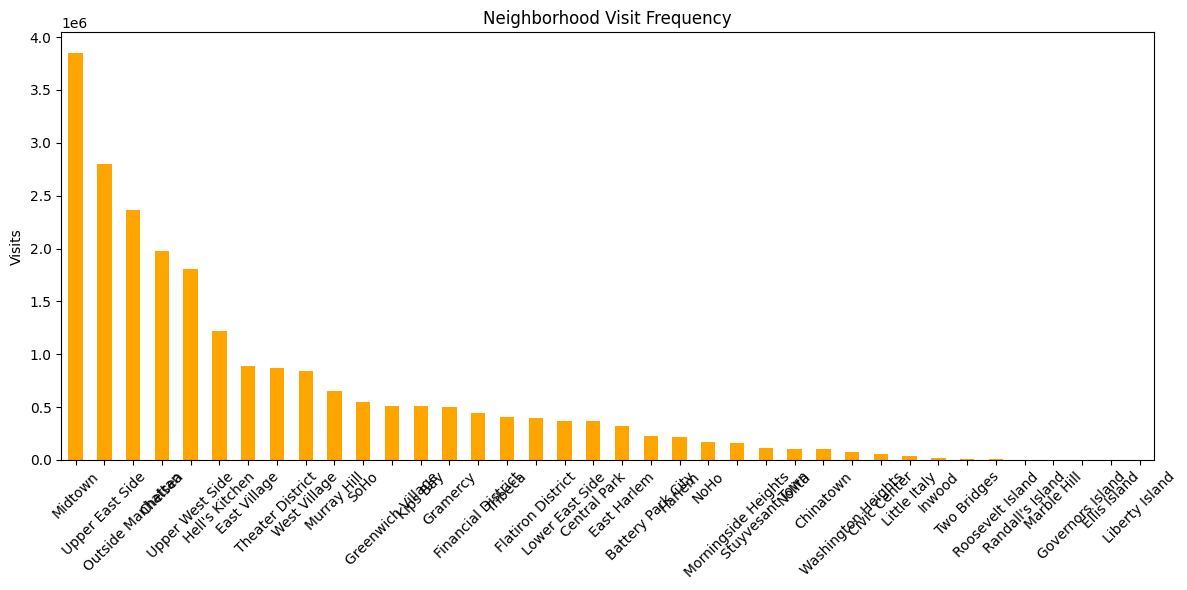

In [75]:
# 📊 Neighborhood visit frequency
visit_freq = pd.Series(visited).value_counts()
plt.figure(figsize=(12, 6))
visit_freq.plot(kind="bar", color="orange")
plt.title("Neighborhood Visit Frequency")
plt.ylabel("Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

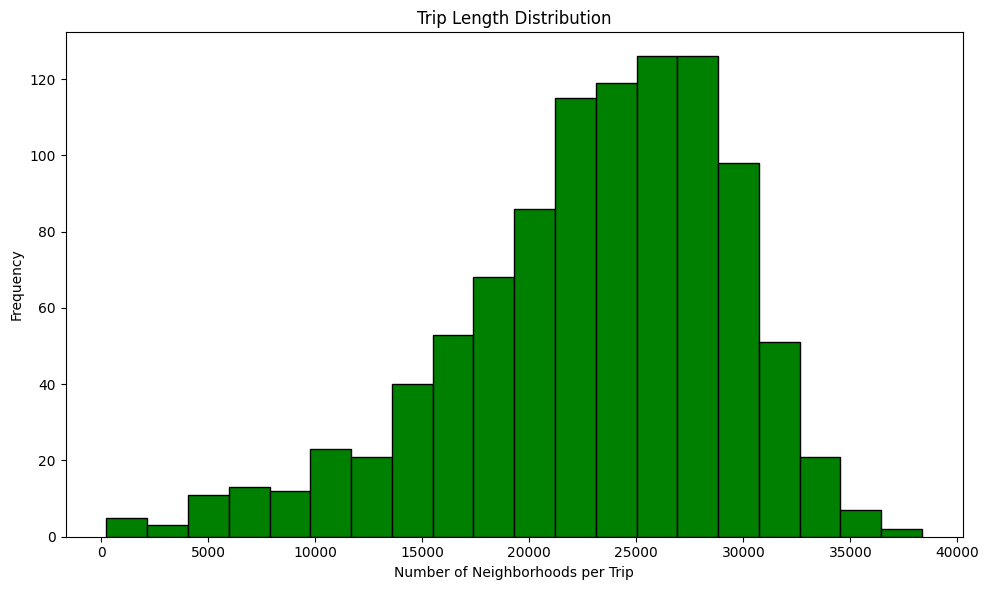

In [76]:
# 📏 Trip length distribution
plt.figure(figsize=(10, 6))
plt.hist(trip_lengths, bins=20, color="green", edgecolor="black")
plt.title("Trip Length Distribution")
plt.xlabel("Number of Neighborhoods per Trip")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [77]:
# 🔁 Loop detection
print(f"\nTotal trips: {len(trajectories)}")
print(f"Trips with loops: {loops}")


Total trips: 1000
Trips with loops: 1000


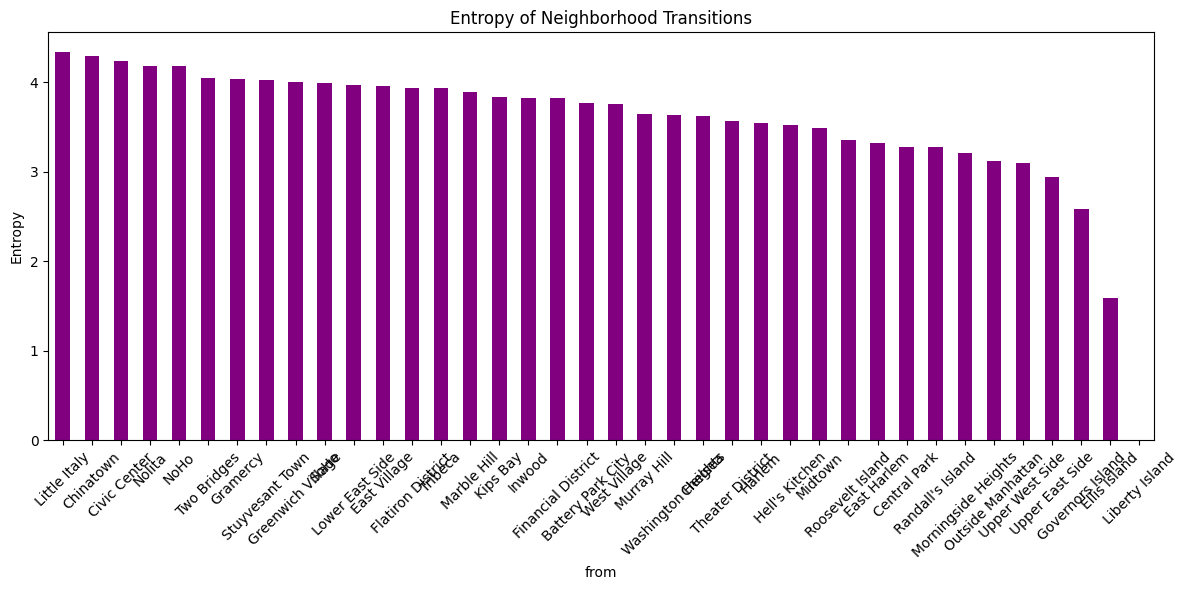

In [78]:
# 📉 Entropy of transitions
def entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

entropies = transition_matrix.apply(entropy, axis=1).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
entropies.plot(kind="bar", color="purple")
plt.title("Entropy of Neighborhood Transitions")
plt.ylabel("Entropy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

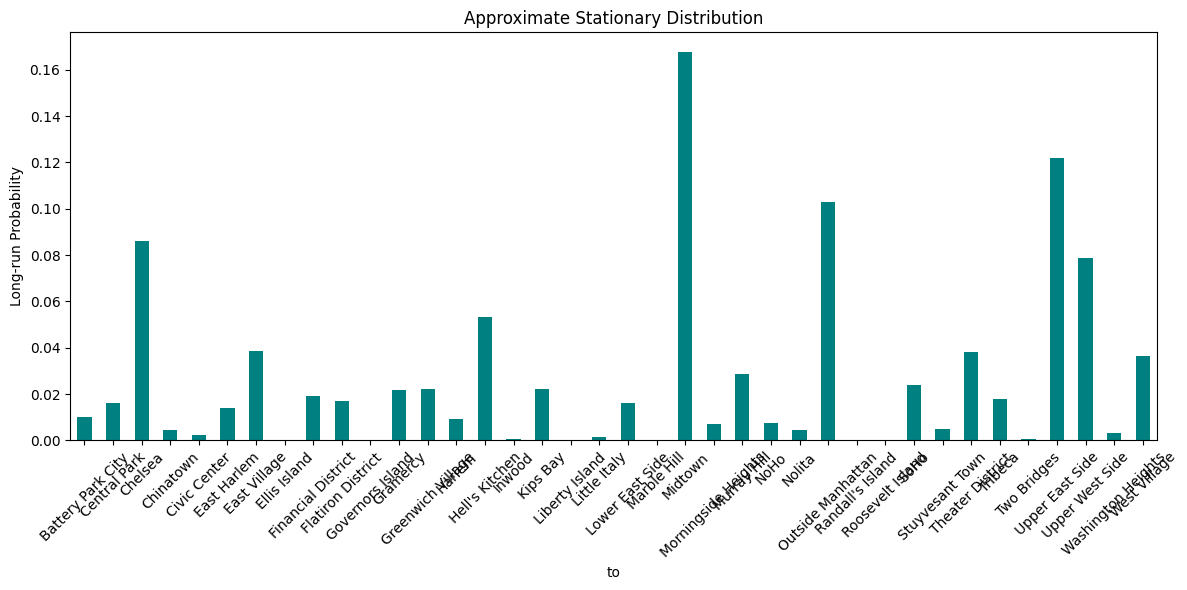

In [79]:
# 📈 Stationary distribution (approximate)
stationary = transition_matrix.copy()
for _ in range(100):
    stationary = stationary @ transition_matrix
stationary_dist = stationary.iloc[0]
plt.figure(figsize=(12, 6))
stationary_dist.plot(kind="bar", color="teal")
plt.title("Approximate Stationary Distribution")
plt.ylabel("Long-run Probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [80]:
# First-order transitions: (A → B)
transitions_1 = []
for traj in trajectories:
    traj = list(traj)
    for i in range(len(traj) - 1):
        transitions_1.append((traj[i], traj[i + 1]))

df1 = pd.DataFrame(transitions_1, columns=["from", "to"])
transition_counts_1 = pd.crosstab(df1["from"], df1["to"])
transition_matrix_1 = transition_counts_1.div(transition_counts_1.sum(axis=1), axis=0)


In [83]:
# Build second-order transition matrix with string keys
transitions_2 = []
for traj in trajectories:
    traj = list(traj)
    for i in range(len(traj) - 2):
        from_pair = f"{traj[i]} → {traj[i + 1]}"
        to_next = traj[i + 2]
        transitions_2.append((from_pair, to_next))

df2 = pd.DataFrame(transitions_2, columns=["from", "to"])
transition_counts_2 = pd.crosstab(df2["from"], df2["to"])
transition_matrix_2 = transition_counts_2.div(transition_counts_2.sum(axis=1), axis=0)


In [84]:
# Compare sparsity
sparsity_1 = (transition_counts_1 == 0).sum().sum() / transition_counts_1.size
sparsity_2 = (transition_counts_2 == 0).sum().sum() / transition_counts_2.size

print("First-order transition matrix shape:", transition_matrix_1.shape)
print("Second-order transition matrix shape:", transition_matrix_2.shape)
print("First-order sparsity:", round(sparsity_1, 4))
print("Second-order sparsity:", round(sparsity_2, 4))

# Top transitions
print("\nTop first-order transitions:")
print(df1.value_counts().head(10))

print("\nTop second-order transitions:")
print(df2.value_counts().head(10))


First-order transition matrix shape: (38, 38)
Second-order transition matrix shape: (1226, 38)
First-order sparsity: 0.151
Second-order sparsity: 0.3002

Top first-order transitions:
from               to               
Midtown            Midtown              1389343
Upper East Side    Upper East Side      1283151
Outside Manhattan  Outside Manhattan    1203902
Upper West Side    Upper West Side       763963
Chelsea            Chelsea               662397
Upper East Side    Midtown               507502
Midtown            Upper East Side       484395
Hell's Kitchen     Hell's Kitchen        346322
Midtown            Chelsea               278191
Chelsea            Midtown               260420
Name: count, dtype: int64

Top second-order transitions:
from                                   to               
Outside Manhattan → Outside Manhattan  Outside Manhattan    616200
Upper East Side → Upper East Side      Upper East Side      414071
Midtown → Midtown                      Midtown      

#### - Explain why taxicabs are most likely order 1, and not 2 or more.

Taxicab trajectories are most likely modeled as order-1 Markov chains because a cab’s next location depends primarily on its current location, not the full history of where it’s been.

Why Order-1 Makes Sense ? 

1. Local Decision-Making
- Drivers make routing decisions based on current pickup/drop-off, traffic, and nearby demand.

- The immediate location is the strongest predictor of where they’ll go next.

2. Sparse Data Problem
- Higher-order models (order-2, order-3…) require exponentially more data to estimate transitions between longer sequences.

- Most datasets don’t have enough repeated patterns to reliably estimate those probabilities.

3. Trajectory Independence
- Cab rides are often independent trips: once a passenger is dropped off, the next trip starts fresh.

- The cab’s location resets to wherever the last drop-off occurred — not influenced by earlier rides.

4. Empirical Evidence
- Transition matrices built from real data show strong predictive power using just the current state.

- Adding more history rarely improves accuracy significantly unless modeling specific behaviors (e.g., shift patterns or driver habits).

When Higher-Order Might Help ?
- If modeling driver behavior over a shift (e.g., looping through hotspots)

- If you have dense, timestamped data and want to capture temporal dependencies

- If you're simulating multi-leg trips or route planning

But for most urban mobility modeling — especially with anonymized or aggregated data — order-1 is the sweet spot: simple, interpretable, and surprisingly powerful.



#### - - Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips

In [86]:
# Forecast function
def forecast(state, T, steps):
    state_vec = pd.Series(0, index=T.columns)
    if state not in state_vec:
        raise ValueError(f"State '{state}' not found in transition matrix.")
    state_vec[state] = 1.0
    history = [state_vec]
    for _ in range(steps):
        state_vec = T.T @ state_vec
        history.append(state_vec)
    return history

In [87]:
# Forecast from Hell's Kitchen
forecasts = forecast("Hell's Kitchen", transition_matrix, 10)

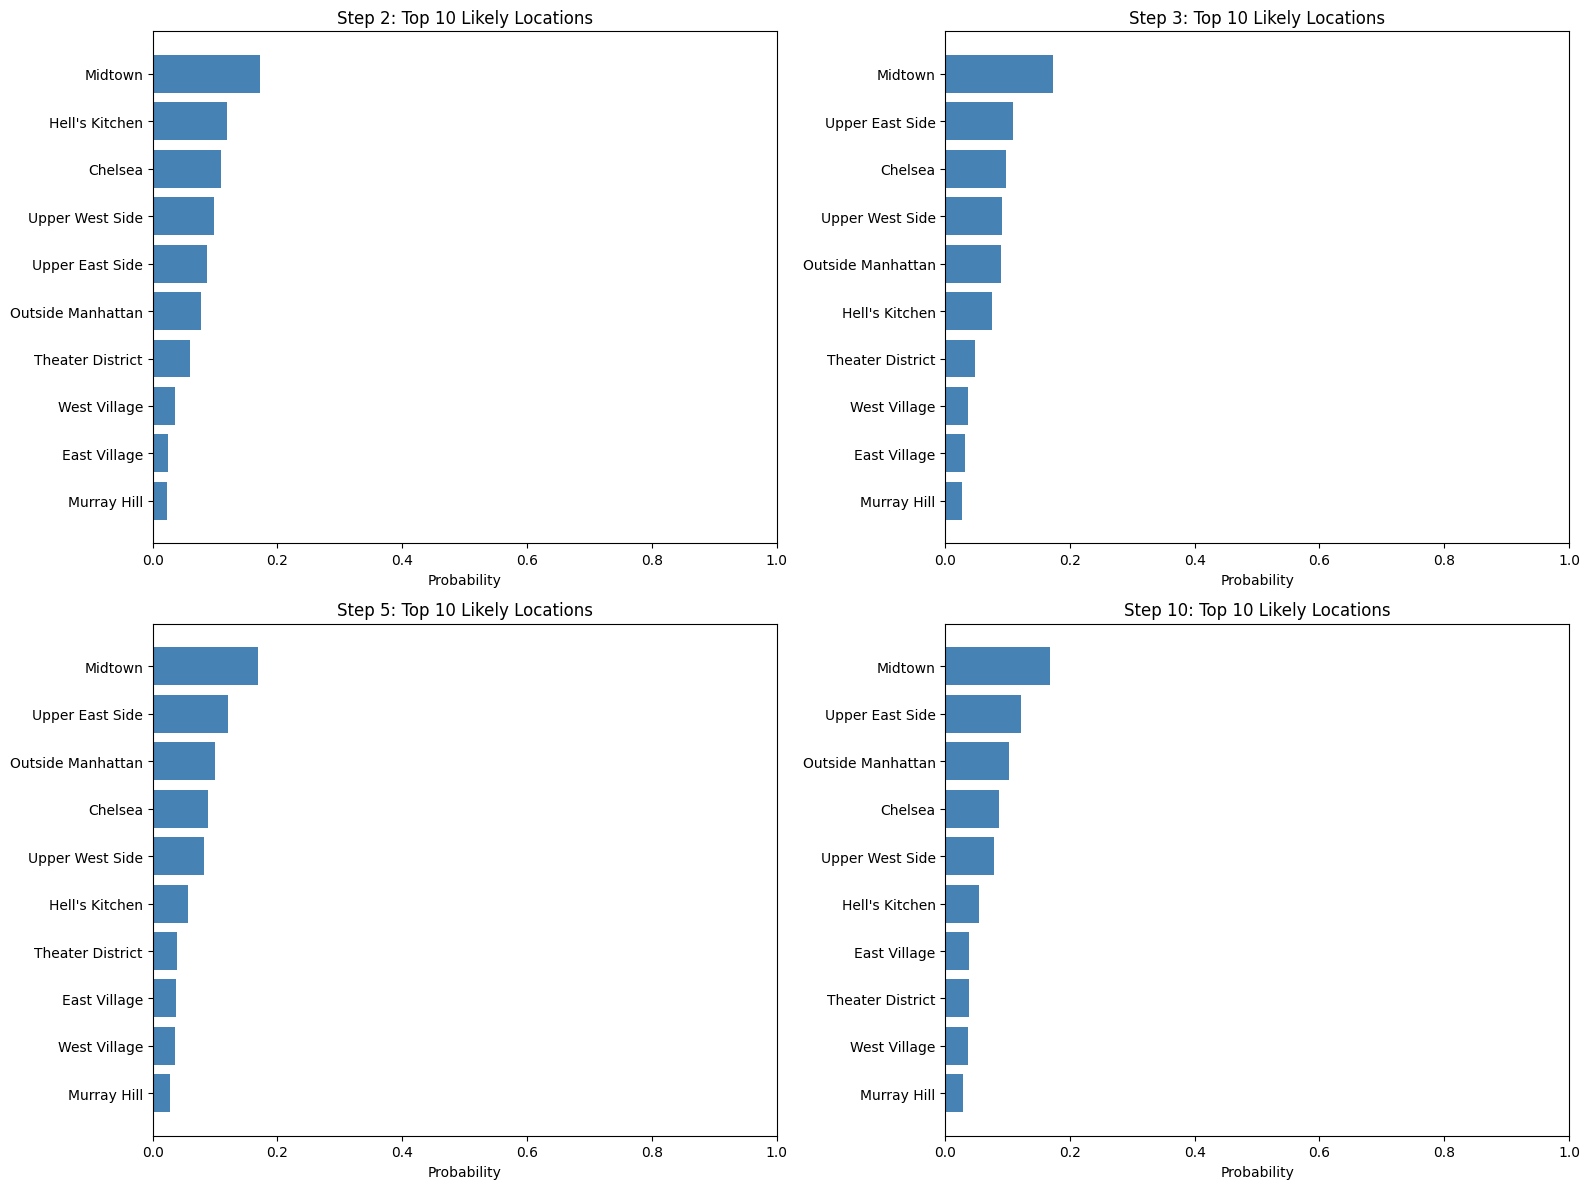

In [89]:
# Plot forecasts at steps 2, 3, 5, and 10
steps_to_plot = [2, 3, 5, 10]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, step in enumerate(steps_to_plot):
    top_states = forecasts[step].sort_values(ascending=False).head(10)
    axes[i].barh(top_states.index[::-1], top_states.values[::-1], color="steelblue")
    axes[i].set_title(f"Step {step}: Top 10 Likely Locations")
    axes[i].set_xlabel("Probability")
    axes[i].set_xlim(0, 1)

plt.tight_layout()
plt.show()

#### - - Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [90]:
# Initialize state vector from any neighborhood
start_state = transition_matrix.index[0]  # arbitrary starting point
state_vec = pd.Series(0, index=transition_matrix.columns)
state_vec[start_state] = 1.0

In [ ]:
# Iterate until convergence
threshold = 1e-8
max_steps = 1000

for step in range(max_steps):
    next_vec = transition_matrix.T @ state_vec
    if np.linalg.norm(next_vec - state_vec, ord=1) < threshold:
        break
    state_vec = next_vec



In [93]:
# Final stationary distribution
stationary_distribution = state_vec.sort_values(ascending=False)
print("Top neighborhoods by long-run cab presence:")
print(stationary_distribution.head(10))

Top neighborhoods by long-run cab presence:
to
Midtown              0.167748
Upper East Side      0.121839
Outside Manhattan    0.102952
Chelsea              0.086153
Upper West Side      0.078541
Hell's Kitchen       0.053318
East Village         0.038700
Theater District     0.038064
West Village         0.036554
Murray Hill          0.028498
dtype: float64


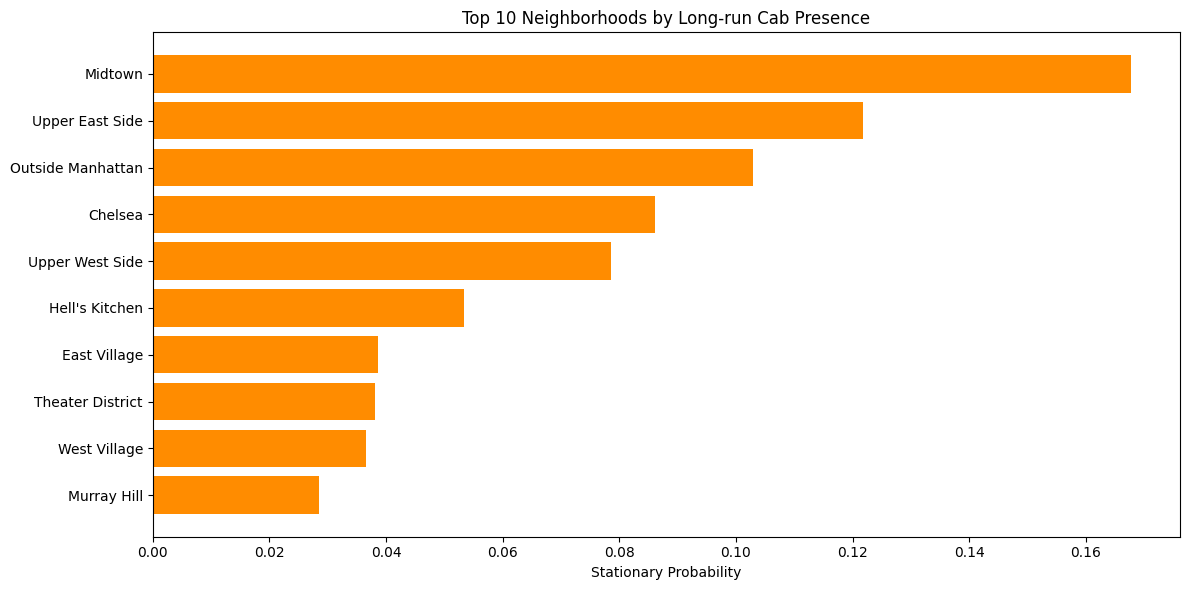

In [94]:
# Plot top 10 neighborhoods
top10 = stationary_distribution.head(10)
plt.figure(figsize=(12, 6))
plt.barh(top10.index[::-1], top10.values[::-1], color="darkorange")
plt.title("Top 10 Neighborhoods by Long-run Cab Presence")
plt.xlabel("Stationary Probability")
plt.tight_layout()
plt.show()